# Step 1: Connect to GPU

Connect the T4 machine on top right

# Step 2: Install Required Libraries
Install necessary libraries such as PyTorch, segmentation_models_pytorch, and other dependencies using pip.

In [2]:
 # Install Required Libraries
!uv pip install -q torch torchvision segmentation-models-pytorch matplotlib pillow ipywidgets tifffile scikit-image

# Step 3: Import Libraries

In [1]:
# Import Necessary Modules
import os
import torch
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt
from torchvision.transforms.functional import to_tensor, resize
import segmentation_models_pytorch as smp

# Step 4: Load the Pretrained Model
Load the saved model weights using `torch.load` and initialize the model architecture.


## Step 4a: download the FAST model
Apart from the link in the manuscript the model can also be downloaded with request access at https://drive.google.com/file/d/1SKEUXr1xOf739tIzdnSMx03lGNaAWY84/view?usp=sharing

## Step 4b: Place the downloaded model (.pth file) in this directory

In [2]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

MODEL_IN_CHANNELS = 1
model = smp.UnetPlusPlus(
    encoder_name="resnet34",
    encoder_weights=None,
    in_channels=MODEL_IN_CHANNELS,
    classes=5  # Number of classes in the segmentation task
).to(device)

# Load the saved model weights downloaded from google drive link above
model_path = "fast_model.pth"

if not os.path.exists(model_path):
    raise FileNotFoundError(
        f"Model weights not found at: {model_path}\n"
        "Set `model_path` to a valid .pth file in this workspace."
    )

state = torch.load(model_path, map_location=device)
model.load_state_dict(state)
model.eval()
print(f"Loaded weights: {model_path}")

Loaded weights: fast_model.pth


# Step5: Interactive preprocessing + inference

## Step 5a: Upload a sample image from your dataset that you want to test

## Step 5b: Provide the path to your file in the box or in the code

## Step 5c: Preform pre processing that gives the best predicted mask with FAST
Use the sliders to tune preprocessing (including rolling-ball background subtraction, default value is 50). When you're happy, click **Run inference** to see the segmentation result on your image.

In [ ]:
import os
import cv2
import numpy as np
import torch
import tifffile as tiff
from PIL import Image
import matplotlib.pyplot as plt
from torchvision import transforms
from skimage.restoration import rolling_ball
import ipywidgets as widgets
from IPython.display import display, clear_output


transform = transforms.Compose([
    transforms.ToTensor(),
])

DEFAULT_IMAGE_PATH = "FAST/TestOutput/TIRF_Fix_HEK_CD8AA-24hrs_100X_2000G7.5%_2000Ph7%_2040WGA3.2%120260422_123800 PM_WGA.png"
# To make this cell runnable even if the preview cell wasn't executed
if "DEFAULT_IMAGE_PATH" not in globals():
    DEFAULT_IMAGE_PATH = "test.tif"

# Set background to white for mask images
def set_background_white(mask_img):
    mask_img = mask_img.copy()
    bg_color = colormap[0]
    mask_img = mask_img.astype(np.float32) / 100.0
    bg_mask = np.all(mask_img == (bg_color / 100.0), axis=-1)
    mask_img[bg_mask] = np.array([1.0, 1.0, 1.0])
    return np.clip(mask_img, 0, 1)

def read_grayscale_image(path: str) -> np.ndarray:
    if path.lower().endswith((".tif", ".tiff")):
        img = tiff.imread(path)
        # Some TIFFs are multi-page or multi-channel; take a reasonable default
        if isinstance(img, np.ndarray) and img.ndim > 2:
            img = img[0]
        if img.ndim == 3:
            img = img[..., 0]
        img = img.astype(np.float32)
    else:
        img = cv2.imread(path, cv2.IMREAD_GRAYSCALE)
        if img is None:
            raise ValueError(f"cv2.imread failed for: {path}")
        img = img.astype(np.float32)
    return img

def preprocess_image_np(img: np.ndarray, bg_radius: int = 50, subtract_background: bool = True,) -> np.ndarray:

    if subtract_background and bg_radius > 0:
        bg = rolling_ball(img, radius=int(bg_radius))
        img = img - bg
    return img

def to_model_tensor(img_2d: np.ndarray) -> torch.Tensor:
    # Ensure we have uint8-ish range for PIL -> ToTensor normalization
    img_2d = np.asarray(img_2d)
    if img_2d.dtype != np.uint8:
        vmin, vmax = float(np.min(img_2d)), float(np.max(img_2d))
        if vmax > vmin:
            img_2d = (255.0 * (img_2d - vmin) / (vmax - vmin)).astype(np.uint8)
        else:
            img_2d = np.zeros_like(img_2d, dtype=np.uint8)

    img_np = Image.fromarray(img_2d).convert("L")
    img = transform(img_np).unsqueeze(0).to(device)
    return img

def decode_segmentation_masks(mask: np.ndarray, colormap: np.ndarray) -> np.ndarray:
    out_rgb = np.zeros((mask.shape[0], mask.shape[1], 3), dtype=np.uint8)
    for cls in range(colormap.shape[0]):
        out_rgb[mask == cls] = colormap[cls]
    return out_rgb

# Class colors (adjust if you have a preferred palette)
# Loading the Colormap
colormap = np.array(
    [
        [0.0, 0.0, 0.0],  # Background - Black
        [0 / 255.0, 180.0 / 255.0, 80.0 / 255.0],  # Actin - Darker Green
        [255.0 / 255.0, 85.0 / 255.0, 255.0 / 255.0],  # Focal Adhesions - Magenta
        [255.0 / 255.0, 165.0 / 255.0, 0.0],  # Lamellipodia - Orange
        [50.0 / 255.0, 120.0 / 255.0, 180.0 / 255.0],  # Filopodia - darker cyan
    ]
)

colormap = colormap * 100
colormap = colormap.astype(np.uint8)
COLORMAP = colormap

# Ensure model is in eval mode once loaded
try:
    model.eval()
except NameError:
    raise RuntimeError("Model is not defined yet. Run the model-loading cell first.")

# Widgets
path_w = widgets.Text(value=DEFAULT_IMAGE_PATH, description="Image path", layout=widgets.Layout(width="80%"))
bg_on_w = widgets.Checkbox(value=True, description="Subtract background")
bg_radius_w = widgets.IntSlider(value=50, min=0, max=200, step=1, description="BG radius")
run_btn = widgets.Button(description="Run inference", button_style="primary")
save_result = widgets.Button(description="Save result", button_style="success", disabled=True)

status_w = widgets.HTML(value="<b>Status:</b> Ready")
progress_w = widgets.IntProgress(value=0, min=0, max=4, description="Progress")
progress_w.layout = widgets.Layout(width="60%")

preview_out = widgets.Output()
results_out = widgets.Output()

# Holds the arrays/path from the most recent successful inference run, so the
# Save button can write them out without re-running the model.
_last_result = {}


def _save_preview_png(raw: np.ndarray, out_path: str) -> None:
    fig, ax = plt.subplots(figsize=(6, 6))
    ax.imshow(raw, cmap="gray")
    ax.set_title(f"Input preview: {os.path.basename(path_w.value.strip())}\nshape={raw.shape}, dtype={raw.dtype}")
    ax.axis("off")
    fig.tight_layout()
    fig.savefig(out_path, dpi=150, bbox_inches="tight")
    plt.close(fig)


def _save_inference_png(raw: np.ndarray, corrected: np.ndarray, rgb: np.ndarray, out_path: str) -> None:
    fig, axes = plt.subplots(1, 3, figsize=(18, 6))
    axes[0].imshow(raw, cmap="gray")
    axes[0].set_title("Original")
    axes[0].axis("off")
    axes[1].imshow(corrected, cmap="gray")
    axes[1].set_title("Preprocessed")
    axes[1].axis("off")
    axes[2].imshow(rgb)
    axes[2].set_title("Prediction")
    axes[2].axis("off")
    fig.tight_layout(rect=[0, 0, 1, 0.95])
    fig.savefig(out_path, dpi=150, bbox_inches="tight")
    plt.close(fig)


def show_input_preview(*_):
    # A new image was loaded/typed, so any previously saved result no longer
    # matches what's on screen — require a fresh "Run inference" before saving.
    _last_result.clear()
    save_result.disabled = True

    with preview_out:
        clear_output(wait=True)
        p = path_w.value.strip()
        if not p:
            print("Enter an image path to preview.")
            return
        if not os.path.exists(p):
            print(f"File not found: {p}")
            return
        try:
            raw = read_grayscale_image(p)
        except Exception as e:
            print(f"Failed to load image: {e}")
            return


        plt.figure(figsize=(6, 6))
        plt.imshow(raw, cmap="gray")
        plt.title(f"Input preview: {os.path.basename(p)}\nshape={raw.shape}, dtype={raw.dtype}")
        plt.axis("off")
        plt.show()


def set_status(text: str, *, bar_style: str = "") -> None:
    status_w.value = f"<b>Status:</b> {text}"
    progress_w.bar_style = bar_style


def _run_inference(_):
    run_btn.disabled = True
    save_result.disabled = True
    progress_w.value = 0
    set_status("Loading image…", bar_style="info")
    try:
        img_path = path_w.value.strip()
        if not img_path:
            raise ValueError("Please provide an image path.")
        if not os.path.exists(img_path):
            raise FileNotFoundError(f"File not found: {img_path}")

        raw = read_grayscale_image(img_path)
        # Always show the input image first (even before preprocessing)
        show_input_preview()
        progress_w.value = 1

        set_status("Preprocessing…", bar_style="info")
        corrected = preprocess_image_np(
            raw,
            bg_radius=int(bg_radius_w.value),
            subtract_background=bool(bg_on_w.value),
        )
        progress_w.value = 2

        set_status("Running model…", bar_style="info")
        img_t = to_model_tensor(corrected)
        with torch.no_grad():
            logits = model(img_t)
            pred = torch.argmax(logits, dim=1).squeeze(0).detach().cpu().numpy().astype(np.int32)
        progress_w.value = 3

        set_status("Rendering…", bar_style="info")
        rgb = decode_segmentation_masks(pred, COLORMAP)
        rgb = set_background_white(rgb)


        with results_out:
            clear_output(wait=True)
            fig, axes = plt.subplots(1, 3, figsize=(18, 6))
            axes[0].imshow(raw, cmap="gray")
            axes[0].set_title("Original")
            axes[0].axis("off")
            axes[1].imshow(corrected, cmap="gray")
            axes[1].set_title("Preprocessed")
            axes[1].axis("off")
            axes[2].imshow(rgb)
            axes[2].set_title("Prediction")
            axes[2].axis("off")
            plt.tight_layout(rect=[0, 0, 1, 0.95])
            plt.show()
        progress_w.value = 4
        set_status("Done", bar_style="success")

        # Stash results for the Save button (show_input_preview() above cleared
        # this, so re-populate it after a successful run).
        _last_result.update(img_path=img_path, raw=raw, corrected=corrected, rgb=rgb)
        save_result.disabled = False
    except Exception as e:
        set_status(f"Error: {e}", bar_style="danger")
        with results_out:
            clear_output(wait=True)
            print(e)
    finally:
        run_btn.disabled = False


def _on_save_click(_):
    # Bridges the button click (which passes only the button instance) to
    # _save_inference_png, which needs the actual image arrays + a path.
    if not _last_result:
        set_status("Nothing to save yet — run inference first.", bar_style="warning")
        return

    save_result.disabled = True
    try:
        img_path = _last_result["img_path"]
        stem = os.path.splitext(os.path.basename(img_path))[0]
        out_dir = os.path.dirname(img_path) or "."
        out_path = os.path.join(out_dir, f"{stem}_prediction.png")

        set_status("Saving…", bar_style="info")
        _save_inference_png(
            _last_result["raw"],
            _last_result["corrected"],
            _last_result["rgb"],
            out_path,
        )
        set_status(f"Saved to {out_path}", bar_style="success")
    except Exception as e:
        set_status(f"Save failed: {e}", bar_style="danger")
    finally:
        save_result.disabled = False


run_btn.on_click(_run_inference)
save_result.on_click(_on_save_click)
path_w.observe(show_input_preview, names="value")

# Initial preview (shows whatever is currently in the textbox)
show_input_preview()

display(
    widgets.VBox(
        [
            path_w,
            preview_out,
            widgets.HBox([bg_on_w, bg_radius_w]),
            widgets.HBox([run_btn, save_result, progress_w, status_w]),
            results_out,
        ]
    )
)

# (optional): Create a persisted snapshot for future reference of predictions

Just for static display to save as widget outputs are not loaded upon reopening

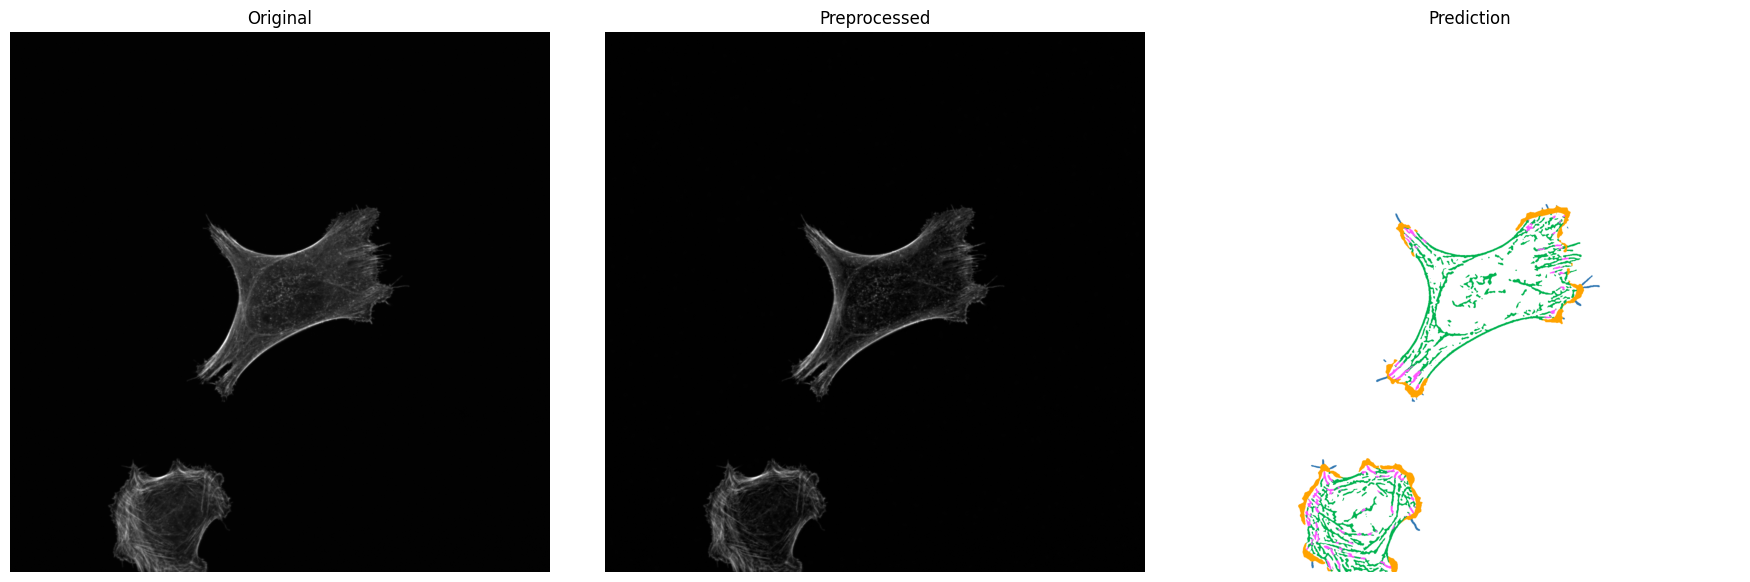

In [5]:
# Static snapshot (this output is saved into the notebook)
# Run this cell after you click the widget's "Run inference" (or anytime) and then save the notebook.

def run_inference_static(
    image_path: str,
    *,
    subtract_background: bool = True,
    bg_radius: int = 50,
    show: bool = True,
 ):
    """Run one inference pass and display as a *normal* cell output (persists when notebook is saved)."""
    if not image_path:
        raise ValueError("Please provide an image path.")
    if not os.path.exists(image_path):
        raise FileNotFoundError(f"File not found: {image_path}")
    
    raw = read_grayscale_image(image_path)
    corrected = preprocess_image_np(
        raw,
        bg_radius=int(bg_radius),
        subtract_background=bool(subtract_background),
    )
    img_t = to_model_tensor(corrected)
    with torch.no_grad():
        logits = model(img_t)
        pred = torch.argmax(logits, dim=1).squeeze(0).detach().cpu().numpy().astype(np.int32)
    rgb = decode_segmentation_masks(pred, COLORMAP)
    rgb = set_background_white(rgb)

    fig, axes = plt.subplots(1, 3, figsize=(18, 6))
    axes[0].imshow(raw, cmap="gray")
    axes[0].set_title("Original")
    axes[0].axis("off")
    axes[1].imshow(corrected, cmap="gray")
    axes[1].set_title("Preprocessed")
    axes[1].axis("off")
    axes[2].imshow(rgb)
    axes[2].set_title("Prediction")
    axes[2].axis("off")
    plt.tight_layout(rect=[0, 0, 1, 0.95])
    if show:
        plt.show()


# Use current widget values if they exist (fallback to defaults)
_image_path = path_w.value.strip() if "path_w" in globals() else DEFAULT_IMAGE_PATH
_subtract_bg = bool(bg_on_w.value) if "bg_on_w" in globals() else True
_bg_radius = int(bg_radius_w.value) if "bg_radius_w" in globals() else 50

run_inference_static(_image_path, subtract_background=_subtract_bg, bg_radius=_bg_radius)